# Separate lemon-leaf input validator

Binary labels: **LEMON_LEAF = 1**, **NOT_LEMON_LEAF = 0**. The frozen InceptionV3 disease classifier is not loaded, modified, or evaluated. This notebook trains and evaluates a separate MobileNetV3Small gate; it does not integrate the gate into the application.

Implementation lives in the reviewable project modules scripts/prepare_leaf_validator_data.py and scripts/leaf_validator_pipeline.py. Run cells in order. Completed training and inference caches are reused on rerun; incomplete runs stop for inspection.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'scripts/leaf_validator_pipeline.py').exists())
sys.path.insert(0,str(ROOT/'scripts'))
import leaf_validator_pipeline as pipeline
from IPython.display import display, Markdown
baseline, dataset_stats = pipeline.setup()

TensorFlow 2.21.0 Devices [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## Data provenance and split preservation

All 2,050 positives keep their **final manifest** assignments; physical directory names have no role. Negatives contain 1,000 bean leaves, 1,000 real object images from 25 explicitly allowed Caltech categories, and 50 synthetic colors/gradients/noise images. Exact decoded-RGB duplicates are removed before deterministic external sampling. Each binary label has 1,435 train, 308 validation, and 307 test images. Synthetic examples are only 35/2,870 training images (1.22%).

TFDS was attempted but its installed download path lacks importlib_resources. Original archive hosts returned HTTP 403, so checksum-verified archive mirrors are used without installing packages. URLs, hashes and category filtering are recorded in negative_provenance.json.

Sources: [Beans catalog](https://www.tensorflow.org/datasets/catalog/beans), [Beans publisher](https://github.com/AI-Lab-Makerere/ibean), [Caltech101 catalog](https://www.tensorflow.org/datasets/catalog/caltech101). Source/session independence of external images is not established. Class-level category filtering does not constitute an exhaustive background audit.

In [2]:
manifest = pipeline.build_dataset()
display(manifest.groupby(['source','split']).size().unstack(fill_value=0))
display(manifest.groupby(['label','split']).size().unstack(fill_value=0))

source      split
beans       test      150
            train     700
            val       150
caltech101  test      150
            train     700
            val       150
lemoscan    test      307
            train    1435
            val       308
synthetic   test        7
            train      35
            val         8
dtype: int64


split,test,train,val
source,,,
beans,150,700,150
caltech101,150,700,150
lemoscan,307,1435,308
synthetic,7,35,8


split,test,train,val
label,,,
LEMON_LEAF,307,1435,308
NOT_LEMON_LEAF,307,1435,308


## Fixed architecture and validation-only development

MobileNetV3Small ImageNet backbone is frozen throughout. Global average pooling, Dropout(0.25), and a single sigmoid output form the lightweight head. No fine-tuning is scheduled. Maximum 12 epochs, Adam 0.001, batch 32, early stopping patience 3, and ReduceLROnPlateau patience 2. The checkpoint with minimum validation loss is retained.

RGB float32 bilinear resize to 224?224 produces values in [0,255]. MobileNetV3's **built-in rescaling** handles normalization; do not apply InceptionV3 preprocessing or divide by 255 externally. Mild flip/rotation/zoom/translation/contrast augmentation is training-only. See [Keras MobileNet documentation](https://keras.io/api/applications/mobilenet/).

Model: "lemon_leaf_validator"
┌─────────────────────────────────┬────────────────────────┬───────────────┐
│ Layer (type)                    │ Output Shape           │       Param # │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rgb_0_255 (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lemon_probability (Dense)       │ (None, 1) 

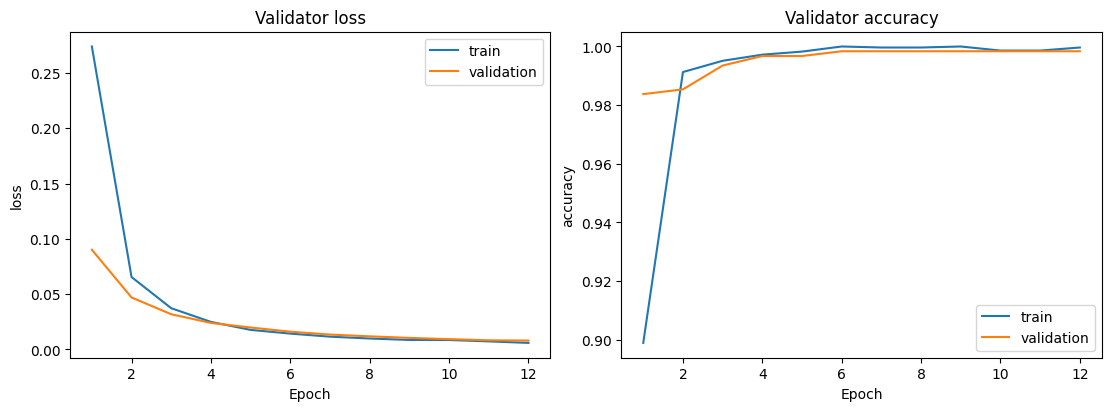

,epoch,accuracy,loss,val_accuracy,val_loss,learning_rate
0,1,0.898955,0.273858,0.983766,0.090143,0.001
1,2,0.991289,0.065482,0.985390,0.047020,0.001
2,3,0.995122,0.037304,0.993506,0.031854,0.001
3,4,0.997213,0.024947,0.996753,0.024023,0.001
4,5,0.998258,0.017709,0.996753,0.019871,0.001
5,6,1.000000,0.014373,0.998377,0.016092,0.001
6,7,0.999652,0.011599,0.998377,0.013487,0.001
7,8,0.999652,0.009933,0.998377,0.011888,0.001
8,9,1.000000,0.008631,0.998377,0.010479,0.001
9,10,0.998606,0.008589,0.998377,0.009360,0.001


In [3]:
history, training_info = pipeline.train_model(manifest)
pipeline.plot_history(history)
display(history)
print(training_info)

## Freeze the acceptance threshold before test inference

Predeclared rule: retain at least **95% validation lemon recall**, reject all validation synthetic negatives, then minimize non-lemon false accepts. Ties prefer higher recall, then closeness to 0.5. If no threshold satisfies those constraints, stop before test evaluation. These are explicit operational objectives, not claims of calibrated confidence.

Threshold candidates are the observed validation probabilities, 0, 0.5 and the point just above the maximum probability. The selected threshold and frozen model hash are written to disk **before constructing the test inference pipeline**.

In [4]:
frozen = pipeline.select_threshold(manifest)
display(pipeline.pd.Series(frozen['validation_metrics']).to_frame('validation'))
print(frozen['method'])

Threshold frozen BEFORE test: 0.397647500038147
{
  "accuracy": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "f1": 1.0,
  "false_accepts": 0,
  "false_rejects": 0,
  "true_accepts": 308,
  "true_rejects": 308,
  "false_positive_rate": 0.0,
  "false_negative_rate": 0.0,
  "images": 616,
  "threshold": 0.397647500038147,
  "confusion_matrix": [
    [
      308,
      0
    ],
    [
      0,
      308
    ]
  ]
}
Predeclared: among validation thresholds retaining at least 95% lemon recall and rejecting all validation synthetic negatives, minimize false accepts; tie-break by highest lemon recall, then threshold closest to 0.5. If infeasible, stop before test; never tune on test or final robustness results.


,validation
accuracy,1.0
precision,1.0
recall,1.0
f1,1.0
false_accepts,0
false_rejects,0
true_accepts,308
true_rejects,308
false_positive_rate,0.0
false_negative_rate,0.0


## One final evaluation

Only now is the 614-image test set passed through the frozen validator. Predictions are cached for report regeneration; neither architecture nor threshold changes afterward. False accepts mean non-lemon images accepted as lemon; false rejects mean real lemon leaves rejected.

{
  "accuracy": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "f1": 1.0,
  "false_accepts": 0,
  "false_rejects": 0,
  "true_accepts": 307,
  "true_rejects": 307,
  "false_positive_rate": 0.0,
  "false_negative_rate": 0.0,
  "images": 614,
  "threshold": 0.397647500038147,
  "confusion_matrix": [
    [
      307,
      0
    ],
    [
      0,
      307
    ]
  ]
}


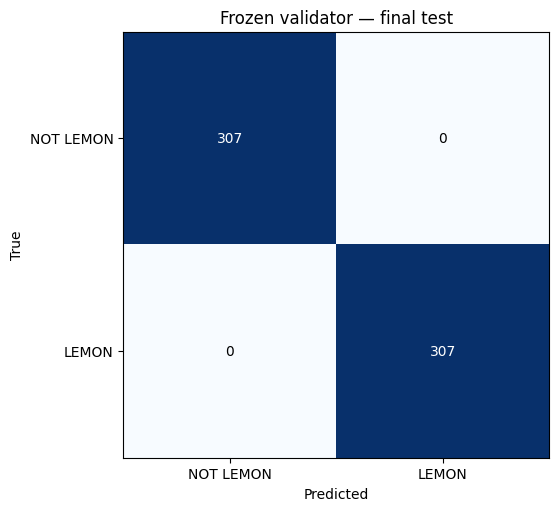

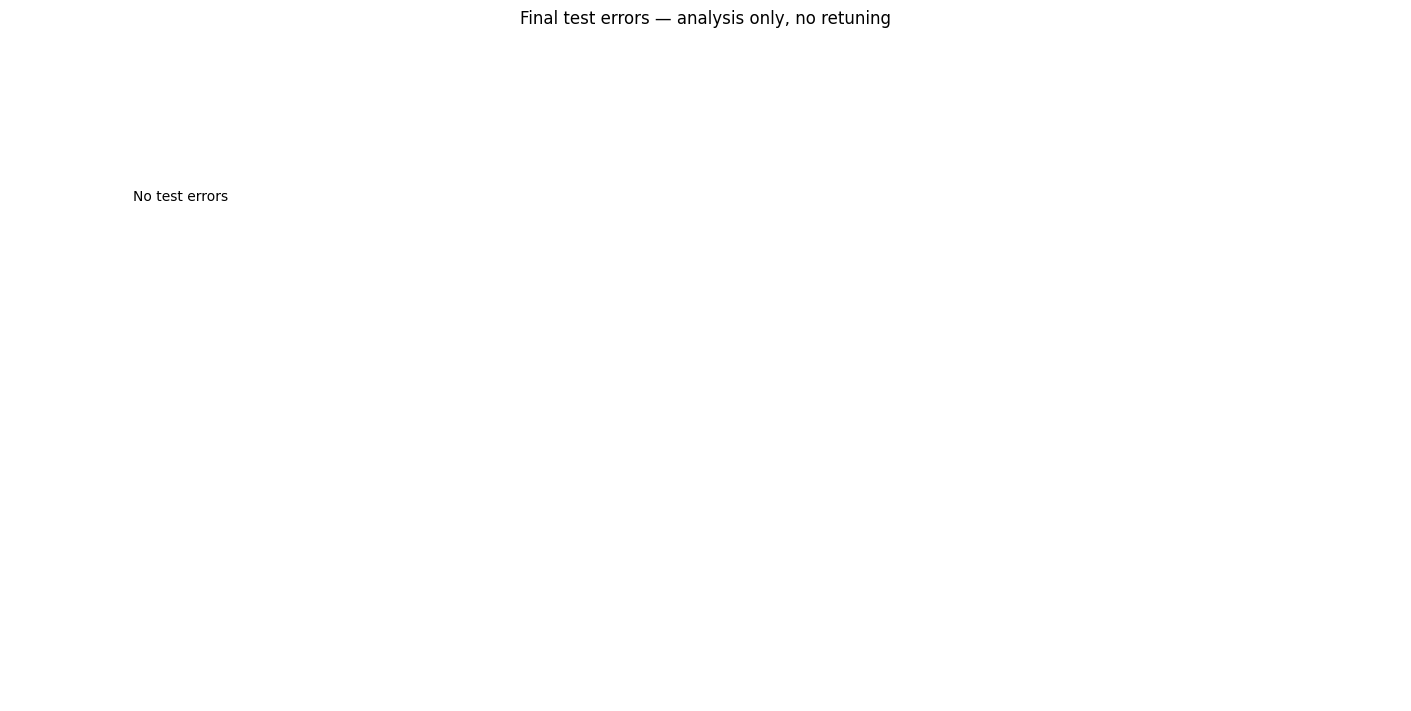

,test
accuracy,1.0
precision,1.0
recall,1.0
f1,1.0
false_accepts,0
false_rejects,0
true_accepts,307
true_rejects,307
false_positive_rate,0.0
false_negative_rate,0.0


In [5]:
test_metrics, test_predictions = pipeline.evaluate_test(manifest, frozen)
display(pipeline.pd.Series(test_metrics).to_frame('test'))

## Required post-freeze robustness checks

Existing test probabilities are reused for six bean leaves, six objects, and six valid lemon leaves. A separate canonical solid-green RGB(0,255,0) image is checked once after freeze. No test or robustness result can trigger retuning. A green false accept blocks readiness and is reported honestly.

In [6]:
robustness = pipeline.robustness(manifest, frozen, test_predictions)
display(pipeline.pd.DataFrame(robustness['cases']))
print('Solid green rejected:', robustness['solid_green_rejected'])

Canonical solid green rejected: True P(lemon): 0.07330690324306488
Solid green rejected: True


,case,filepath,lemon_probability,accepted,expected_accept
0,beans,data/leaf_validator/external/a87a4140a2fce72c9...,1.005878e-03,False,False
1,beans,data/leaf_validator/external/259062e54557ba3c2...,8.036197e-03,False,False
2,beans,data/leaf_validator/external/ce13ecc8a6951e616...,4.433403e-03,False,False
3,beans,data/leaf_validator/external/3e2bf84f8dcda68e7...,1.349002e-03,False,False
4,beans,data/leaf_validator/external/193a0a0a76f780933...,3.497336e-05,False,False
5,beans,data/leaf_validator/external/0f105f3812f627c6d...,1.187045e-03,False,False
6,caltech101,data/leaf_validator/external/febaf460da4981c81...,4.295866e-06,False,False
7,caltech101,data/leaf_validator/external/e5ae9f435c9fdf3c8...,4.828759e-07,False,False
8,caltech101,data/leaf_validator/external/2119f3ff9b2ab852a...,5.398642e-05,False,False
9,caltech101,data/leaf_validator/external/86346c0754edc4a8a...,1.100542e-05,False,False


## Integrity, limitations and saved artifacts

The original source images, disease models, disease evaluation reports, shared disease inference utilities and both apps are protected by integrity checks. This gate is not a universal species verifier: other citrus leaves and real-world camera/domain variation need broader testing. The existing 410 unresolved C/D cross-split candidates remain a positive-data limitation.

**Completed run:** 12 frozen-backbone epochs in 556.82 seconds. The validation-selected threshold is 0.397647500038147. Validation: 616/616 correct; final test: 614/614 correct, with zero false accepts and zero false rejects. Canonical solid green was rejected (score 0.0733069). The threshold below 0.5 recovered validation lemon recall without introducing observed validation false accepts; it is not a calibrated probability cutoff. Perfect observed results on this constructed benchmark are not evidence of universal real-world accuracy. All required robustness examples passed. No app integration or post-test retuning occurred.

In [7]:
summary = pipeline.finalize(manifest, training_info, frozen, test_metrics, robustness, baseline, dataset_stats)
print('Saved:', pipeline.MODEL)
print('Training seconds:', summary['training']['training_seconds'])
print(summary['test_integrity'])
print(summary['limitation'])
print('App integration:', summary['integrated_into_app'])

Saved: E:\LemoScan-AI\model\lemon_leaf_validator.keras
Training seconds: 556.8218262999981
Model and acceptance threshold were frozen before one test inference pass. No post-test retuning.
This is a dataset-specific binary gate, not a universal lemon-species verifier. Bean/object source domains differ from LemoScan. Other citrus species and broader field conditions are not covered. 410 unresolved LemoScan C/D candidate pairs cross splits; complete biological-source independence is not proven.
App integration: False
